# BLIP-2 Image Captioning + Visual Question Answering Semester Project

**Project:** Image Caption Generation and Visual Question Answering using BLIP-2  
**Model:** `Salesforce/blip2-opt-2.7b`  
**Platform:** Google Colab GPU  

## Main Outputs
1. Generate caption from image
2. Answer questions about image
3. Run batch captioning on a folder of images
4. Save results in CSV
5. Optional evaluation using ground-truth captions
6. Optional Gradio demo app

**Roman Urdu Note:**  
Is notebook me hum BLIP-2 ko scratch se train nahi kar rahe. Hum pretrained BLIP-2 use karenge, kyun ke semester project ke liye yeh practical aur GPU-friendly approach hai.

## 0. Colab Runtime

Before running:
1. Go to **Runtime**
2. Click **Change runtime type**
3. Select **GPU**
4. Run cells from top to bottom

Recommended GPU: T4 / L4 / A100  
Colab Free par T4 mil jaye to 4-bit quantization use karen.

In [4]:
# Check GPU
!nvidia-smi

Mon Jun  1 06:03:18 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1. Install Required Libraries

`transformers` BLIP-2 model load karne ke liye use hoti hai.  
`bitsandbytes` 4-bit/8-bit quantization ke liye use hoti hai taake GPU memory kam lage.  
`gradio` optional web app demo ke liye use hoti hai.

In [2]:
!pip -q install -U transformers accelerate bitsandbytes pillow pandas tqdm matplotlib gradio nltk rouge-score

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 72.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 57.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 65.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.1/20.1 MB 56.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 56.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.3/73.3 kB 5.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are 

In [2]:
# ============================================================
# Install Required Libraries - Safe Version for Google Colab
# ============================================================

# Step 1: Install main libraries without force-upgrading Colab system packages
!pip -q install transformers accelerate bitsandbytes rouge-score nltk gradio

# Step 2: Restore Colab-compatible pandas version
!pip -q install "pandas==2.2.2"

# Step 3: Fix starlette version conflict for Google Colab / Gradio
!pip -q install "starlette>=0.49.1,<1.0.0"

# Step 4: Show installed versions
import pandas as pd
import transformers
import torch
import gradio as gr

print("Installation completed.")
print("pandas:", pd.__version__)
print("transformers:", transformers.__version__)
print("torch:", torch.__version__)
print("gradio:", gr.__version__)

Installation completed.
pandas: 2.2.2
transformers: 5.0.0
torch: 2.11.0+cu128
gradio: 5.50.0


## 2. Imports and Basic Setup

In [5]:
import os
import glob
import time
import json
import shutil
import warnings
from pathlib import Path

import torch
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

from transformers import AutoProcessor, Blip2ForConditionalGeneration, BitsAndBytesConfig

warnings.filterwarnings("ignore")

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU not found. Please enable GPU in Colab Runtime.")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


## 3. Mount Google Drive and Create Project Folders

Roman Urdu:  
Drive mount karne se generated captions, CSV files, sample outputs aur logs save rahenge. Runtime disconnect hone ke baad bhi files lose nahi hongi.

In [6]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = "/content/drive/MyDrive/BLIP2_Semester_Project"
IMAGE_DIR = os.path.join(PROJECT_DIR, "images")
OUTPUT_DIR = os.path.join(PROJECT_DIR, "outputs")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")
LOGS_DIR = os.path.join(PROJECT_DIR, "logs")

for folder in [PROJECT_DIR, IMAGE_DIR, OUTPUT_DIR, RESULTS_DIR, LOGS_DIR]:
    os.makedirs(folder, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Put your test images here:", IMAGE_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project directory: /content/drive/MyDrive/BLIP2_Semester_Project
Put your test images here: /content/drive/MyDrive/BLIP2_Semester_Project/images


## 4. Model Configuration

Default model: `Salesforce/blip2-opt-2.7b`

**Important:**  
Colab Free par memory issue aa sakta hai. Is liye default loading mode 4-bit rakha gaya hai.

Options:
- `LOAD_IN_4BIT = True` → recommended for Colab Free
- `LOAD_IN_8BIT = True` → agar 4-bit issue kare
- Float16 → high VRAM GPU par

In [7]:
MODEL_ID = "Salesforce/blip2-opt-2.7b"

# Colab Free ke liye recommended
LOAD_IN_4BIT = True
LOAD_IN_8BIT = False

# Generation settings
MAX_NEW_TOKENS = 50
NUM_BEAMS = 5

print("Model:", MODEL_ID)
print("4-bit:", LOAD_IN_4BIT, "| 8-bit:", LOAD_IN_8BIT)

Model: Salesforce/blip2-opt-2.7b
4-bit: True | 8-bit: False


## 5. Load BLIP-2 Processor and Model

Roman Urdu:  
Processor image/text ko model input format me convert karta hai.  
Model visual features aur language model ko use karke caption/answer generate karta hai.

In [8]:
processor = AutoProcessor.from_pretrained(MODEL_ID)

if torch.cuda.is_available():
    if LOAD_IN_4BIT:
        quantization_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_compute_dtype=torch.float16,
            bnb_4bit_use_double_quant=True,
            bnb_4bit_quant_type="nf4"
        )

        model = Blip2ForConditionalGeneration.from_pretrained(
            MODEL_ID,
            quantization_config=quantization_config,
            device_map="auto"
        )

    elif LOAD_IN_8BIT:
        quantization_config = BitsAndBytesConfig(load_in_8bit=True)

        model = Blip2ForConditionalGeneration.from_pretrained(
            MODEL_ID,
            quantization_config=quantization_config,
            device_map="auto"
        )

    else:
        model = Blip2ForConditionalGeneration.from_pretrained(
            MODEL_ID,
            torch_dtype=torch.float16,
            device_map="auto"
        )
else:
    # CPU mode slow hoga, lekin small testing ke liye run ho sakta hai.
    model = Blip2ForConditionalGeneration.from_pretrained(MODEL_ID)

model.eval()

MODEL_DEVICE = next(model.parameters()).device
print("Model loaded on:", MODEL_DEVICE)

processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/1.03k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/882 [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/122k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1247 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

Model loaded on: cuda:0


## 6. Helper Functions

Yeh functions:
1. Image load karenge
2. Caption generate karenge
3. Image ke question ka answer generate karenge
4. Results save karenge

In [9]:
def load_image(image_path):
    """
    Image path se RGB image load karta hai.
    """
    image = Image.open(image_path).convert("RGB")
    return image


def prepare_inputs(image, text=None):
    """
    Processor inputs banata hai aur tensors ko correct device par move karta hai.
    input_ids integer rehte hain, pixel_values float16 me ja sakti hain.
    """
    if text is None:
        inputs = processor(images=image, return_tensors="pt")
    else:
        inputs = processor(images=image, text=text, return_tensors="pt")

    device = next(model.parameters()).device
    new_inputs = {}

    for key, value in inputs.items():
        if isinstance(value, torch.Tensor):
            value = value.to(device)
            if key == "pixel_values" and torch.cuda.is_available():
                value = value.to(torch.float16)
            new_inputs[key] = value
        else:
            new_inputs[key] = value

    return new_inputs


def generate_caption(image, max_new_tokens=50, num_beams=5):
    """
    Image caption generate karta hai.
    """
    inputs = prepare_inputs(image)

    with torch.inference_mode():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            num_beams=num_beams,
            early_stopping=True
        )

    caption = processor.decode(output_ids[0], skip_special_tokens=True).strip()
    return caption


def answer_question(image, question, max_new_tokens=30, num_beams=5):
    """
    Visual Question Answering.
    BLIP-2 prompt format:
    Question: ... Answer:
    """
    prompt = f"Question: {question} Answer:"
    inputs = prepare_inputs(image, text=prompt)

    with torch.inference_mode():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            num_beams=num_beams,
            early_stopping=True
        )

    answer = processor.decode(output_ids[0], skip_special_tokens=True).strip()
    return answer


def show_image(image, title=None):
    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()

## 7. Single Image Test

Apni image upload karo ya Drive folder me image rakho.

Option A: Colab upload  
Option B: Drive path use karo

In [10]:
# Option A: Upload image from your computer
from google.colab import files

uploaded = files.upload()

uploaded_image_path = None
for filename in uploaded.keys():
    uploaded_image_path = filename
    # Copy image to project image folder
    shutil.copy(filename, os.path.join(IMAGE_DIR, filename))
    print("Uploaded:", filename)

print("Current image path:", uploaded_image_path)

Saving download (2).jpg to download (2).jpg
Uploaded: download (2).jpg
Current image path: download (2).jpg


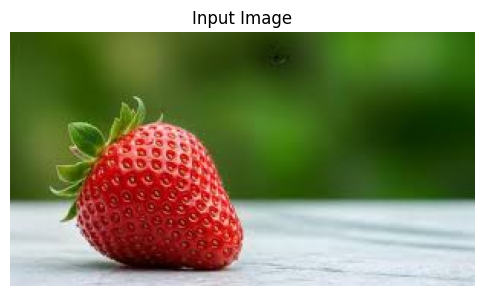

Generated Caption:
a strawberry sitting on top of a wooden table


In [12]:
# Option B: If you already have image in Drive, set path manually
# Example:
# uploaded_image_path = "/content/drive/MyDrive/BLIP2_Semester_Project/images/my_image.jpg"

if uploaded_image_path is None:
    raise ValueError("/content/drive/MyDrive/BLIP2_Semester_Project/images")

image = load_image(uploaded_image_path)
show_image(image, "Input Image")

caption = generate_caption(
    image,
    max_new_tokens=MAX_NEW_TOKENS,
    num_beams=NUM_BEAMS
)

print("Generated Caption:")
print(caption)

## 8. Visual Question Answering Test

Roman Urdu:  
Ab image ke baare me question pucho. Model image ko dekh kar answer generate karega.

In [13]:
question = "What is happening in this image?"

answer = answer_question(
    image,
    question=question,
    max_new_tokens=30,
    num_beams=NUM_BEAMS
)

print("Question:", question)
print("Answer:", answer)

Question: What is happening in this image?
Answer: Question: What is happening in this image? Answer: A strawberry is being eaten by a bee


In [14]:
# Try more questions
questions = [
    "What objects are visible in the image?",
    "How many people are in the image?",
    "What is the main action in the image?",
    "Describe the scene briefly."
]

for q in questions:
    ans = answer_question(image, q)
    print("Q:", q)
    print("A:", ans)
    print("-" * 60)

Q: What objects are visible in the image?
A: Question: What objects are visible in the image? Answer: A strawberry
------------------------------------------------------------
Q: How many people are in the image?
A: Question: How many people are in the image? Answer: 1
------------------------------------------------------------
Q: What is the main action in the image?
A: Question: What is the main action in the image? Answer: A strawberry is sitting on a table
------------------------------------------------------------
Q: Describe the scene briefly.
A: Question: Describe the scene briefly. Answer: A strawberry is sitting on a table in front of a green background
------------------------------------------------------------


## 9. Batch Captioning on Folder

Roman Urdu:  
Agar tumhare paas multiple images hain, unko `IMAGE_DIR` folder me rakho. Yeh code sab images par caption generate karke CSV save karega.

In [15]:
SUPPORTED_EXTENSIONS = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]

def list_images(folder):
    image_paths = []
    for ext in SUPPORTED_EXTENSIONS:
        image_paths.extend(glob.glob(os.path.join(folder, f"*{ext}")))
        image_paths.extend(glob.glob(os.path.join(folder, f"*{ext.upper()}")))
    return sorted(list(set(image_paths)))


image_paths = list_images(IMAGE_DIR)
print("Total images found:", len(image_paths))
print(image_paths[:5])

Total images found: 4
['/content/drive/MyDrive/BLIP2_Semester_Project/images/1001773457_577c3a7d70.jpg', '/content/drive/MyDrive/BLIP2_Semester_Project/images/download (2).jpg', '/content/drive/MyDrive/BLIP2_Semester_Project/images/download (3).jpg', '/content/drive/MyDrive/BLIP2_Semester_Project/images/download (4).jpg']


In [16]:
batch_results = []

start_time = time.time()

for img_path in tqdm(image_paths):
    try:
        img = load_image(img_path)
        t0 = time.time()
        cap = generate_caption(img, max_new_tokens=MAX_NEW_TOKENS, num_beams=NUM_BEAMS)
        inference_time = time.time() - t0

        batch_results.append({
            "image_path": img_path,
            "image_name": os.path.basename(img_path),
            "generated_caption": cap,
            "inference_time_sec": round(inference_time, 4)
        })

    except Exception as e:
        batch_results.append({
            "image_path": img_path,
            "image_name": os.path.basename(img_path),
            "generated_caption": "",
            "inference_time_sec": None,
            "error": str(e)
        })

total_time = time.time() - start_time

results_df = pd.DataFrame(batch_results)
csv_path = os.path.join(RESULTS_DIR, "blip2_generated_captions.csv")
results_df.to_csv(csv_path, index=False)

print("Saved CSV:", csv_path)
print("Total batch time:", round(total_time, 2), "seconds")
results_df.head()

  0%|          | 0/4 [00:00<?, ?it/s]

Saved CSV: /content/drive/MyDrive/BLIP2_Semester_Project/results/blip2_generated_captions.csv
Total batch time: 7.53 seconds


,image_path,image_name,generated_caption,inference_time_sec
0,/content/drive/MyDrive/BLIP2_Semester_Project/...,1001773457_577c3a7d70.jpg,a black and white dog,1.4366
1,/content/drive/MyDrive/BLIP2_Semester_Project/...,download (2).jpg,a strawberry sitting on top of a wooden table,1.6932
2,/content/drive/MyDrive/BLIP2_Semester_Project/...,download (3).jpg,a tiger swimming in the water,1.2332
3,/content/drive/MyDrive/BLIP2_Semester_Project/...,download (4).jpg,a woman taking a photo with a camera,2.0153


## 10. Visualize Batch Results

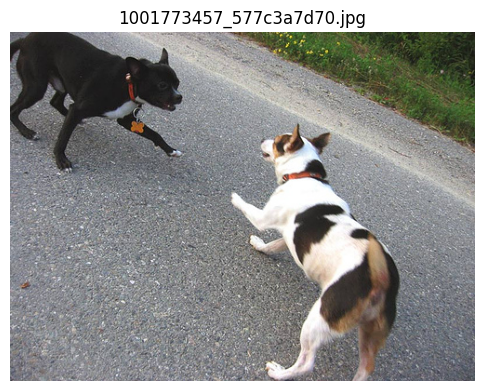

Generated Caption: a black and white dog
--------------------------------------------------------------------------------


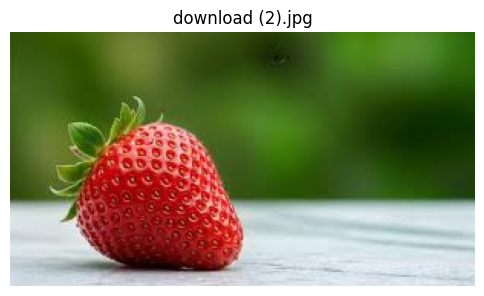

Generated Caption: a strawberry sitting on top of a wooden table
--------------------------------------------------------------------------------


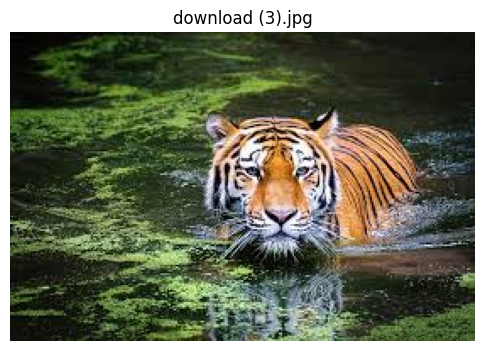

Generated Caption: a tiger swimming in the water
--------------------------------------------------------------------------------


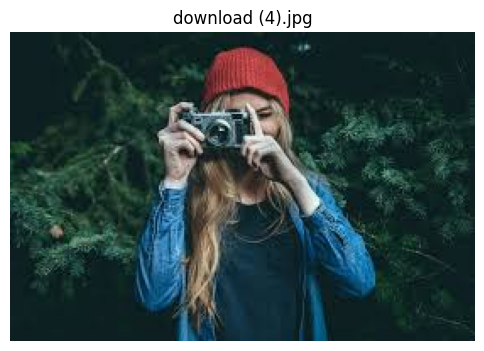

Generated Caption: a woman taking a photo with a camera
--------------------------------------------------------------------------------


In [17]:
def visualize_predictions(df, n=5):
    sample_df = df.head(n)

    for _, row in sample_df.iterrows():
        img = load_image(row["image_path"])
        show_image(img, row["image_name"])
        print("Generated Caption:", row["generated_caption"])
        print("-" * 80)


if len(results_df) > 0:
    visualize_predictions(results_df, n=min(5, len(results_df)))
else:
    print("No images found for visualization.")

## 11. Optional Evaluation with Ground Truth Captions

Agar tum Flickr8k ya apna custom dataset use kar rahe ho, to ek CSV banao:

```text
image_name,ground_truth_caption
image1.jpg,A dog is playing in the park.
image2.jpg,A man is riding a bicycle.
```

CSV path set karo:
`GROUND_TRUTH_CSV = "..."`

In [18]:
# Set your ground-truth CSV path here
GROUND_TRUTH_CSV = os.path.join(PROJECT_DIR, "ground_truth_captions.csv")

# Example CSV format:
# image_name,ground_truth_caption
# img1.jpg,A dog is running in the grass.
# img2.jpg,A person is riding a bike.

print("Expected ground-truth CSV path:", GROUND_TRUTH_CSV)
print("File exists:", os.path.exists(GROUND_TRUTH_CSV))

Expected ground-truth CSV path: /content/drive/MyDrive/BLIP2_Semester_Project/ground_truth_captions.csv
File exists: False


In [19]:
import nltk
nltk.download("punkt", quiet=True)
nltk.download("wordnet", quiet=True)

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer

def tokenize(text):
    if not isinstance(text, str):
        return []
    return text.lower().strip().split()


def compute_sentence_bleu(reference, candidate):
    # BLEU score simple sentence-level computation.
    ref_tokens = tokenize(reference)
    cand_tokens = tokenize(candidate)

    if len(ref_tokens) == 0 or len(cand_tokens) == 0:
        return 0.0

    smoothie = SmoothingFunction().method4
    score = sentence_bleu(
        [ref_tokens],
        cand_tokens,
        weights=(0.25, 0.25, 0.25, 0.25),
        smoothing_function=smoothie
    )
    return float(score)


def compute_rouge_l(reference, candidate):
    scorer = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)
    scores = scorer.score(reference, candidate)
    return float(scores["rougeL"].fmeasure)


def evaluate_captions(pred_df, gt_csv):
    # pred_df: generated captions dataframe
    # gt_csv: CSV with columns image_name and ground_truth_caption
    gt_df = pd.read_csv(gt_csv)

    required_cols = {"image_name", "ground_truth_caption"}
    if not required_cols.issubset(set(gt_df.columns)):
        raise ValueError(f"Ground truth CSV must contain columns: {required_cols}")

    merged = pred_df.merge(gt_df, on="image_name", how="inner")

    if len(merged) == 0:
        raise ValueError("No matching image_name found between predictions and ground truth CSV.")

    bleu_scores = []
    rouge_l_scores = []

    for _, row in merged.iterrows():
        ref = row["ground_truth_caption"]
        cand = row["generated_caption"]

        bleu_scores.append(compute_sentence_bleu(ref, cand))
        rouge_l_scores.append(compute_rouge_l(ref, cand))

    merged["BLEU"] = bleu_scores
    merged["ROUGE_L"] = rouge_l_scores

    summary = {
        "num_evaluated_images": len(merged),
        "mean_BLEU": sum(bleu_scores) / len(bleu_scores),
        "mean_ROUGE_L": sum(rouge_l_scores) / len(rouge_l_scores)
    }

    return merged, summary


if os.path.exists(GROUND_TRUTH_CSV):
    eval_df, eval_summary = evaluate_captions(results_df, GROUND_TRUTH_CSV)

    eval_csv_path = os.path.join(RESULTS_DIR, "blip2_caption_evaluation.csv")
    eval_json_path = os.path.join(RESULTS_DIR, "blip2_evaluation_summary.json")

    eval_df.to_csv(eval_csv_path, index=False)

    with open(eval_json_path, "w") as f:
        json.dump(eval_summary, f, indent=4)

    print("Evaluation Summary:")
    print(json.dumps(eval_summary, indent=4))
    print("Saved evaluation CSV:", eval_csv_path)
    print("Saved summary JSON:", eval_json_path)

    eval_df.head()
else:
    print("Ground truth CSV not found. Skipping evaluation.")
    print("Create CSV at:", GROUND_TRUTH_CSV)

Ground truth CSV not found. Skipping evaluation.
Create CSV at: /content/drive/MyDrive/BLIP2_Semester_Project/ground_truth_captions.csv


## 12. Save Project Config and Model Info

Roman Urdu:  
Report me use karne ke liye model/config info save kar dete hain.

In [20]:
project_info = {
    "project_title": "Image Caption Generation and Visual Question Answering using BLIP-2",
    "model_id": MODEL_ID,
    "load_in_4bit": LOAD_IN_4BIT,
    "load_in_8bit": LOAD_IN_8BIT,
    "max_new_tokens": MAX_NEW_TOKENS,
    "num_beams": NUM_BEAMS,
    "project_dir": PROJECT_DIR,
    "image_dir": IMAGE_DIR,
    "results_dir": RESULTS_DIR,
    "created_time": time.strftime("%Y-%m-%d %H:%M:%S")
}

info_path = os.path.join(LOGS_DIR, "project_info.json")
with open(info_path, "w") as f:
    json.dump(project_info, f, indent=4)

print("Saved project info:", info_path)
print(json.dumps(project_info, indent=4))

Saved project info: /content/drive/MyDrive/BLIP2_Semester_Project/logs/project_info.json
{
    "project_title": "Image Caption Generation and Visual Question Answering using BLIP-2",
    "model_id": "Salesforce/blip2-opt-2.7b",
    "load_in_4bit": true,
    "load_in_8bit": false,
    "max_new_tokens": 50,
    "num_beams": 5,
    "project_dir": "/content/drive/MyDrive/BLIP2_Semester_Project",
    "image_dir": "/content/drive/MyDrive/BLIP2_Semester_Project/images",
    "results_dir": "/content/drive/MyDrive/BLIP2_Semester_Project/results",
    "created_time": "2026-06-01 06:14:08"
}


## 13. Optional Gradio Web App

Roman Urdu:  
Is se simple web interface ban jayega jahan image upload karke caption aur VQA answer le sakte ho.

In [21]:
import gradio as gr

def gradio_caption_and_vqa(input_image, question):
    if input_image is None:
        return "Please upload an image.", ""

    img = input_image.convert("RGB")

    cap = generate_caption(img, max_new_tokens=MAX_NEW_TOKENS, num_beams=NUM_BEAMS)

    if question is None or question.strip() == "":
        ans = "No question provided."
    else:
        ans = answer_question(img, question, max_new_tokens=30, num_beams=NUM_BEAMS)

    return cap, ans


demo = gr.Interface(
    fn=gradio_caption_and_vqa,
    inputs=[
        gr.Image(type="pil", label="Upload Image"),
        gr.Textbox(label="Question for VQA", value="What is happening in this image?")
    ],
    outputs=[
        gr.Textbox(label="Generated Caption"),
        gr.Textbox(label="Answer")
    ],
    title="BLIP-2 Image Captioning and VQA",
    description="Upload an image. BLIP-2 will generate a caption and answer your question."
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4c15f7266d2353b2d7.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 14. Report Points

Use these points in your semester report:

### Introduction
BLIP-2 is a vision-language model used for image captioning, visual question answering, and image-to-text generation.

### Architecture
BLIP-2 connects:
1. Frozen Image Encoder
2. Q-Former
3. Frozen Large Language Model

### Methodology
1. Input image is loaded and converted to RGB.
2. BLIP-2 processor converts image/question into tensors.
3. Pretrained BLIP-2 model generates caption or answer.
4. Results are saved in CSV.
5. Optional BLEU and ROUGE-L evaluation is performed.

### Advantages
- No need to train from scratch
- Works for captioning and VQA
- Good for zero-shot image understanding
- Practical for semester project

### Limitations
- Requires GPU for efficient inference
- Large model size
- Sometimes may hallucinate incorrect details
- Fine-tuning needs more GPU memory